## TSB-AD Quick Start

### Run AD Model

In this tutorial, we demonstrate how to (i) load a univariate or multivariate time series from the TSB-AD benchmark, (ii) run an unsupervised anomaly detector, and (iii) evaluate its detection quality using standard measures.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
from TSB_AD.model_wrapper import run_Unsupervise_AD
from TSB_AD.evaluation.metrics import get_metrics

# Specify Anomaly Detector to use and data directory
AD_Name = 'IForest'   # It can be replaced with any anomaly detector availale in TSB-AD
data_direc = '../Datasets/TSB-AD-M/018_Daphnet_id_1_HumanActivity_tr_9693_1st_20732.csv'
#data_direc = '/home/nicol/spectral-benchmark/datasets/raw/ScenariosV4_lite/SA1_20250604_092334_ALPS_0.csv'

# Loading Data
df = pd.read_csv(data_direc).dropna()
data = df.iloc[:, 0:-1].values.astype(float)
#data = df.iloc[:, 1:-1].values.astype(float)

label = df['Label'].astype(int).to_numpy()
#label = df['ANOMALY?'].astype(int).to_numpy()

print("Loaded data with shape:", data.shape)
print("Loaded labels with shape:", label.shape)

# Applying Anomaly Detector
output = run_Unsupervise_AD(AD_Name, data)

# Evaluation
evaluation_result = get_metrics(output, label)

print("Evaluation results:\n", evaluation_result)

Loaded data with shape: (38774, 9)
Loaded labels with shape: (38774,)
Evaluation results:
 {'AUC-PR': 0.13242292956158566, 'AUC-ROC': 0.8147292649540744, 'VUS-PR': 0.14476636364699455, 'VUS-ROC': 0.823893517013741, 'Standard-F1': 0.27547557995036365, 'PA-F1': 0.5190889726364083, 'Event-based-F1': 0.28551303122798755, 'R-based-F1': 0.2877941690483259, 'Affiliation-F': 0.7960469043925171}


### Plot Time Series with Ground Truth Anomalies

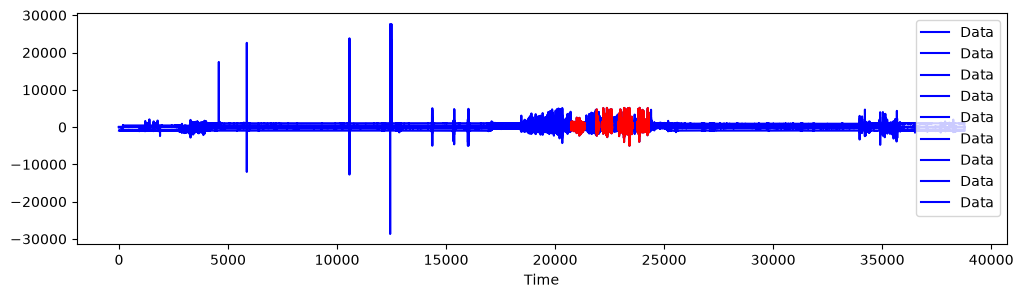

In [3]:
import matplotlib.pyplot as plt
from TSB_AD.evaluation.basic_metrics import basic_metricor

grader = basic_metricor()
range_anomaly = grader.range_convers_new(label)
fig, ax = plt.subplots(figsize=(12, 3))  # Adjust the figure size as needed
ax.plot(range(len(data)), data, color='blue', linewidth=1.5, label='Data')
for r in range_anomaly:
    if r[0] == r[1]:
        ax.plot(r[0], data[r[0]], 'ro', markersize=10)
    else:
        ax.plot(range(r[0], r[1] + 1), data[r[0]:r[1] + 1], color='red', linewidth=1.5) 
plt.legend()
plt.xlabel('Time')
plt.show()